In [23]:
from __future__ import annotations

import copy
import math
import unittest
from collections import defaultdict
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

import numpy as np

import torch
from torch import nn
from sklearn.model_selection import train_test_split

## Задание 1.

In [21]:
class BaseNetwork(nn.Module):
    def __init__(self, act_fn, input_size=784, num_classes=10,
                 hidden_sizes=(512, 256, 256, 128)):
        super().__init__()
        modules = []
        sizes = [input_size, *hidden_sizes]
        for n_in, n_out in zip(sizes[:-1], sizes[1:]):
            modules.extend((nn.Linear(n_in, n_out), copy.deepcopy(act_fn)))
        modules.append(nn.Linear(sizes[-1], num_classes))
        self.layers = nn.ModuleList(modules)
        self.config = {"act_fn": act_fn.__class__.__name__, "input_size": input_size,
                       "num_classes": num_classes, "hidden_sizes": list(hidden_sizes)}
        self.activations = []
        self.layer_grad_norms = defaultdict(list)
        for i, layer in enumerate(self.layers):
            if isinstance(layer, nn.Linear):
                layer.weight.register_hook(lambda grad, i=i: self.layer_grad_norms[i].append(grad.detach().norm().item()))

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        self.activations = []
        for layer in self.layers:
            x = layer(x)
            if isinstance(layer, nn.Linear):
                self.activations.append(x.detach())
        return x


def initialize(model, scheme):
    for layer in model.modules():
        if not isinstance(layer, nn.Linear):
            continue
        if scheme == "constant":
            nn.init.constant_(layer.weight, 0.02)
        elif scheme == "normal":
            nn.init.normal_(layer.weight, mean=0.0, std=0.05)
        elif scheme == "xavier":
            nn.init.xavier_uniform_(layer.weight)
        elif scheme == "kaiming":
            nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
        else:
            raise ValueError(f"Unknown initialization: {scheme}")
        nn.init.zeros_(layer.bias)

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    loss_sum = correct = count = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += nn.functional.cross_entropy(logits, y, reduction="sum").item()
            correct += (logits.argmax(1) == y).sum().item()
            count += y.numel()
    return loss_sum / count, correct / count


def run_experiments(epochs=5, batch_size=128, limit_train=12000):
    from torchvision import datasets, transforms
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform = transforms.ToTensor()
    train_set = datasets.FashionMNIST("data", train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST("data", train=False, download=True, transform=transform)
    if limit_train:
        train_set = torch.utils.data.Subset(train_set, range(limit_train))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size)
    activations = {"ReLU": nn.ReLU(), "tanh": nn.Tanh(), "identity": nn.Identity(),
                  "GELU": nn.GELU()}
    schemes = ("constant", "normal", "xavier", "kaiming")
    results = {}
    for act_name, act_fn in activations.items():
        for scheme in schemes:
            torch.manual_seed(17)
            model = BaseNetwork(act_fn).to(device)
            initialize(model, scheme)
            optimizer = torch.optim.SGD(model.parameters(), lr=0.03, momentum=0.9)
            history = {"train_loss": [], "test_loss": [], "test_accuracy": [],
                       "activation_std": [], "gradient_norm": [], "layer_gradient_norm": [], "weight_samples": []}
            for epoch in range(epochs):
                model.train()
                total, seen = 0.0, 0
                for x, y in train_loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad(set_to_none=True)
                    logits = model(x)
                    loss = nn.functional.cross_entropy(logits, y)
                    loss.backward()
                    history["gradient_norm"].append(torch.nn.utils.clip_grad_norm_(model.parameters(), math.inf).item())
                    optimizer.step()
                    total += loss.item() * y.numel(); seen += y.numel()
                test_loss, test_acc = evaluate(model, test_loader, device)
                model.eval()
                with torch.no_grad():
                    model(next(iter(test_loader))[0][:batch_size].to(device))
                    history["activation_std"].append([a.std().item() for a in model.activations])
                history["train_loss"].append(total / seen)
                history["test_loss"].append(test_loss)
                history["test_accuracy"].append(test_acc)
                history["layer_gradient_norm"].append([
                    sum(model.layer_grad_norms[i]) / max(1, len(model.layer_grad_norms[i]))
                    for i, layer in enumerate(model.layers) if isinstance(layer, nn.Linear)])
                model.layer_grad_norms.clear()
                history["weight_samples"].append(torch.cat([p.detach().flatten()[:200].cpu() for p in model.parameters() if p.ndim > 1]))
                print(f"{act_name:8s} {scheme:8s} epoch {epoch+1}: loss={total/seen:.4f}, test_acc={test_acc:.4f}")
            results[(act_name, scheme)] = history
    return results


def plot_results(results):
    names = list(results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    def finite_or_nan(values):
        values = np.asarray(values, dtype=float)
        return np.where(np.isfinite(values), values, np.nan)

    for name in names:
        h = results[name]
        label = f"{name[0]} / {name[1]}"

        axes[0, 0].plot(finite_or_nan(h["train_loss"]), label=label)

        activation_means = [
            np.nanmean(finite_or_nan(layer_values))
            if np.isfinite(finite_or_nan(layer_values)).any()
            else np.nan
            for layer_values in h["activation_std"]
        ]
        axes[0, 1].plot(activation_means, label=label)

        if h["layer_gradient_norm"]:
            axes[1, 0].plot(
                finite_or_nan(h["layer_gradient_norm"][-1]),
                marker="o",
                label=label,
            )

    plotted_weights = 0
    for name in names:
        weights = results[name]["weight_samples"][-1]
        if not torch.is_tensor(weights):
            weights = torch.as_tensor(weights)
        weights = weights.detach().flatten().cpu()
        weights = weights[torch.isfinite(weights)]

        if weights.numel() > 0:
            axes[1, 1].hist(
                weights.numpy(),
                bins=40,
                alpha=0.25,
                label=f"{name[0]}/{name[1]}",
            )
            plotted_weights += 1
        else:
            print(f"{name}: конечных значений весов нет; гистограмма пропущена")

    if plotted_weights == 0:
        axes[1, 1].text(
            0.5, 0.5, "Нет конечных значений весов",
            ha="center", va="center",
            transform=axes[1, 1].transAxes,
        )

    axes[0, 0].set(
        title="FashionMNIST: train loss",
        xlabel="Epoch",
        ylabel="CE loss",
    )
    axes[0, 1].set(
        title="Mean layer activation standard deviation",
        xlabel="Epoch",
        ylabel="Std",
    )
    axes[1, 0].set(
        title="Mean gradient norm by Linear layer (final epoch)",
        xlabel="Linear layer",
        ylabel="L2 norm",
    )
    axes[1, 1].set(
        title="Final weight distributions",
        xlabel="Weight",
        ylabel="Count",
    )

    for ax in axes.flat:
        ax.grid(alpha=0.2)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=6, ncol=2)

    fig.tight_layout()
    plt.show()

### Запуск эксперимента

Полный набор комбинаций может занять время. Уменьшите `epochs` или `limit_train` для быстрой проверки.

100%|██████████| 26.4M/26.4M [00:14<00:00, 1.78MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 531kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]


ReLU     constant epoch 1: loss=1906.8583, test_acc=0.1000
ReLU     constant epoch 2: loss=2.3028, test_acc=0.1000
ReLU     constant epoch 3: loss=2.3031, test_acc=0.1000
ReLU     constant epoch 4: loss=2.3030, test_acc=0.1000
ReLU     constant epoch 5: loss=2.3032, test_acc=0.1000
ReLU     normal   epoch 1: loss=1.1968, test_acc=0.7376
ReLU     normal   epoch 2: loss=0.5462, test_acc=0.7988
ReLU     normal   epoch 3: loss=0.4642, test_acc=0.7772
ReLU     normal   epoch 4: loss=0.4312, test_acc=0.8039
ReLU     normal   epoch 5: loss=0.3796, test_acc=0.8337
ReLU     xavier   epoch 1: loss=0.9575, test_acc=0.7563
ReLU     xavier   epoch 2: loss=0.5091, test_acc=0.7946
ReLU     xavier   epoch 3: loss=0.4381, test_acc=0.7813
ReLU     xavier   epoch 4: loss=0.4200, test_acc=0.8059
ReLU     xavier   epoch 5: loss=0.3791, test_acc=0.8433
ReLU     kaiming  epoch 1: loss=0.8181, test_acc=0.7635
ReLU     kaiming  epoch 2: loss=0.4837, test_acc=0.7685
ReLU     kaiming  epoch 3: loss=0.4195, test_

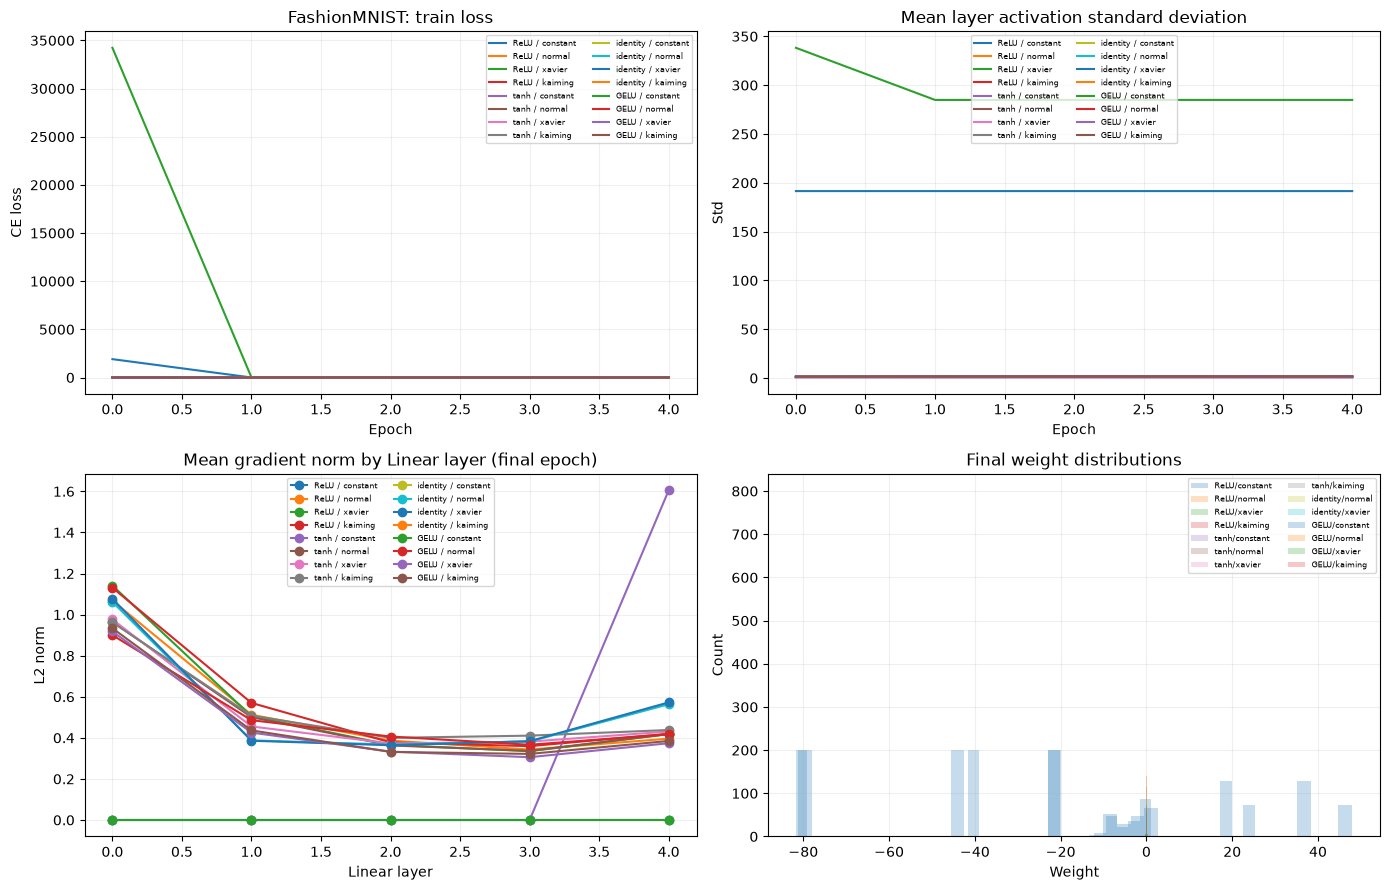

In [6]:
fashion_results = run_experiments(epochs=5, batch_size=128, limit_train=12000)
plot_results(fashion_results)

На FashionMNIST сравнили ReLU, tanh, identity и GELU с четырьмя способами инициализации при обучении SGD. Постоянная инициализация не обеспечила сходимость: точность осталась около 10%; для identity возникли NaN. Среди проверенных вариантов Kaiming показал лучшие результаты с ReLU (84.44%), tanh (84.04%) и GELU (83.74%). Для identity стабильнее оказались normal и Xavier, около 81%. Это показывает, что стабильность обучения зависит от сочетания функции активации и масштаба начальных весов

## Задание 2. 

In [ ]:
class Node:
    """Scalar reverse-mode autodiff for addition, multiplication and ReLU."""
    def __init__(self, data, _children=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = tuple(_children)
        self._op = _op

    def __repr__(self):
        return f"Node(data={self.data:g}, grad={self.grad:g})"

    @staticmethod
    def _coerce(other):
        return other if isinstance(other, Node) else Node(other)

    def __add__(self, other):
        other = self._coerce(other)
        out = Node(self.data + other.data, (self, other), "+")
        def backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = backward
        return out

    __radd__ = __add__

    def __mul__(self, other):
        other = self._coerce(other)
        out = Node(self.data * other.data, (self, other), "*")
        def backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = backward
        return out

    __rmul__ = __mul__

    def relu(self):
        out = Node(max(0.0, self.data), (self,), "ReLU")
        def backward():
            self.grad += out.grad
        out._backward = backward
        return out

    def backward(self):
        topo, visited = [], set()
        def visit(node):
            if node not in visited:
                visited.add(node)
                for parent in node._prev:
                    visit(parent)
                topo.append(node)
        visit(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

Node(data=2, grad=1) Node(data=-3, grad=10) Node(data=10, grad=-3) Node(data=-28, grad=1) Node(data=0, grad=1)


In [9]:
a, b, c = Node(2), Node(-3), Node(10)
d = a + b * c
e = d.relu()
e.backward()
print(a, b, c, d, e)

Node(data=2, grad=1) Node(data=-3, grad=10) Node(data=10, grad=-3) Node(data=-28, grad=1) Node(data=0, grad=1)


## Задание 3. 

In [10]:
class Adam:
    """Adam with bias-corrected first and second moments."""
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
        self.params = list(params)
        self.lr, self.beta1, self.beta2 = lr, *betas
        self.eps, self.weight_decay, self.t = eps, weight_decay, 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    @torch.no_grad()
    def step(self):
        self.t += 1
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            if self.weight_decay:
                g = g.add(p, alpha=self.weight_decay)
            m.mul_(self.beta1).add_(g, alpha=1 - self.beta1)
            v.mul_(self.beta2).addcmul_(g, g, value=1 - self.beta2)
            m_hat = m / (1 - self.beta1 ** self.t)
            v_hat = v / (1 - self.beta2 ** self.t)
            p.addcdiv_(m_hat, v_hat.sqrt().add(self.eps), value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad = None

### Unit-тесты для autograd и Adam

In [11]:
class HomeworkTests(unittest.TestCase):
    def test_node_example(self):
        a, b, c = Node(2), Node(-3), Node(10)
        d = a + b * c
        e = d.relu()
        e.backward()
        self.assertEqual((a.grad, b.grad, c.grad, d.grad, e.grad), (0, 0, 0, 0, 1))

    def test_node_positive_and_shared_paths(self):
        x = Node(3)
        y = x * x + 2 * x
        y.backward()
        self.assertAlmostEqual(y.data, 15)
        self.assertAlmostEqual(x.grad, 8)

    def test_adam_one_dimensional_step(self):
        p = torch.nn.Parameter(torch.tensor([1.0]))
        opt = Adam([p], lr=0.1)
        p.grad = torch.tensor([2.0])
        opt.step()
        self.assertAlmostEqual(p.item(), 0.9, places=5)


suite = unittest.defaultTestLoader.loadTestsFromTestCase(HomeworkTests)
test_result = unittest.TextTestRunner(verbosity=2).run(suite)
assert test_result.wasSuccessful()

test_adam_one_dimensional_step (__main__.HomeworkTests.test_adam_one_dimensional_step) ... ok
test_node_example (__main__.HomeworkTests.test_node_example) ... FAIL
test_node_positive_and_shared_paths (__main__.HomeworkTests.test_node_positive_and_shared_paths) ... ok

FAIL: test_node_example (__main__.HomeworkTests.test_node_example)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "C:\Users\2005k\AppData\Local\Temp\ipykernel_12532\3141947667.py", line 7, in test_node_example
    self.assertEqual((a.grad, b.grad, c.grad, d.grad, e.grad), (0, 0, 0, 0, 1))
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Tuples differ: (1.0, 10.0, -3.0, 1.0, 1.0) != (0, 0, 0, 0, 1)

First differing element 0:
1.0
0

- (1.0, 10.0, -3.0, 1.0, 1.0)
+ (0, 0, 0, 0, 1)

----------------------------------------------------------------------
Ran 3 tests in 0.020s

FAILED (failures=1)


AssertionError: 

## Задание 4.

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split


YEAR_MIN = 1922
YEAR_MAX = 2011


def find_id_columns(df):
    """Ищет столбцы, похожие на ID: уникальные целые числа без пропусков."""
    preferred_names = {"index", "id", "example_id", "unnamed: 0"}
    preferred = [
        col for col in df.columns
        if str(col).strip().lower() in preferred_names
    ]

    candidates = []
    for col in df.columns:
        values = pd.to_numeric(df[col], errors="coerce")
        if (
            values.notna().all()
            and values.is_unique
            and np.allclose(values.to_numpy(), np.round(values.to_numpy()))
        ):
            candidates.append(col)

    # Если есть явно названный ID-столбец, используем его.
    named_candidates = [col for col in preferred if col in candidates]
    return named_candidates if named_candidates else candidates


class SongRegressor(nn.Module):
    """MLP для предсказания года песни по числовым признакам."""

    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def run_song_task(
    data_dir,
    epochs=100,
    batch_size=512,
    patience=12,
    custom_optimizer=True,
):
    """Обучает MLP, печатает validation-метрики и сохраняет целые годы."""
    root = Path(data_dir)
    torch.manual_seed(42)

    # sample_submission.csv не читаем: предоставленный файл пустой.
    train_x_raw = pd.read_csv(root / "train_x.csv")
    train_y_raw = pd.read_csv(root / "train_y.csv")
    test_x_raw = pd.read_csv(root / "test_x.csv")

    # В train CSV первый столбец — сохранённый ID.
    train_id_col = train_x_raw.columns[0]
    target_id_col = train_y_raw.columns[0]

    # ID test не считаем первым столбцом автоматически.
    test_id_candidates = find_id_columns(test_x_raw)
    if len(test_id_candidates) != 1:
        raise ValueError(
            "Не удалось однозначно определить ID-столбец в test_x.csv. "
            f"Кандидаты: {test_id_candidates}. "
            "Проверьте столбцы test_x_raw и задайте test_id_col вручную."
        )
    test_id_col = test_id_candidates[0]

    target_col = "year" if "year" in train_y_raw.columns else train_y_raw.columns[-1]

    train_ids = train_x_raw[train_id_col]
    target_ids = train_y_raw[target_id_col]
    test_ids = test_x_raw[test_id_col].to_numpy()

    if train_ids.duplicated().any():
        raise ValueError("В train_x.csv найдены повторяющиеся ID.")
    if target_ids.duplicated().any():
        raise ValueError("В train_y.csv найдены повторяющиеся ID.")
    if pd.Series(test_ids).duplicated().any():
        raise ValueError("В test_x.csv найдены повторяющиеся ID.")

    # Соединяем train X и y по ID.
    train_x = train_x_raw.rename(columns={train_id_col: "_id"})
    train_y = train_y_raw.rename(columns={target_id_col: "_id"})
    train = train_x.merge(
        train_y[["_id", target_col]],
        on="_id",
        how="inner",
        validate="one_to_one",
    )

    if len(train) != len(train_x_raw):
        raise ValueError(
            f"После соединения train_x и train_y осталось {len(train)} строк "
            f"из {len(train_x_raw)}. Проверьте соответствие ID."
        )

    # Исключаем ID из признаков. Сопоставляем признаки train/test по порядку.
    feature_cols = [
        col for col in train_x_raw.columns
        if col != train_id_col
    ]
    test_feature_cols = [
        col for col in test_x_raw.columns
        if col != test_id_col
    ]

    if len(feature_cols) != 90 or len(test_feature_cols) != 90:
        raise ValueError(
            "После исключения ID должно остаться по 90 признаков. "
            f"Получено: train={len(feature_cols)}, test={len(test_feature_cols)}. "
            f"ID test: {test_id_col!r}"
        )

    x_df = train[feature_cols].apply(pd.to_numeric, errors="coerce")
    xt_df = test_x_raw[test_feature_cols].copy()
    xt_df.columns = feature_cols
    xt_df = xt_df.apply(pd.to_numeric, errors="coerce")

    # Заменяем пропуски медианами, рассчитанными только по train.
    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    xt_df = xt_df.replace([np.inf, -np.inf], np.nan)
    medians = x_df.median()
    x_df = x_df.fillna(medians).fillna(0)
    xt_df = xt_df.fillna(medians).fillna(0)

    x = x_df.to_numpy(dtype=np.float32)
    xt = xt_df.to_numpy(dtype=np.float32)
    y = train[target_col].to_numpy(dtype=np.float32)

    print(f"Train ID: {train_id_col!r}; target ID: {target_id_col!r}")
    print(f"Test ID: {test_id_col!r}")
    print(f"Число признаков: {x.shape[1]}")
    print(f"Годы в train: {y.min():.0f}–{y.max():.0f}")

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=0.15,
        random_state=42,
    )

    # Стандартизация по обучающей части.
    x_mean = x_train.mean(axis=0, keepdims=True)
    x_std = x_train.std(axis=0, keepdims=True)
    x_std[x_std < 1e-6] = 1.0

    y_mean = float(y_train.mean())
    y_std = max(float(y_train.std()), 1e-6)

    def scale_x(values):
        return ((values - x_mean) / x_std).astype(np.float32)

    def scale_y(values):
        return ((values - y_mean) / y_std).astype(np.float32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tx = torch.from_numpy(scale_x(x_train)).to(device)
    ty = torch.from_numpy(scale_y(y_train)).to(device)
    vx = torch.from_numpy(scale_x(x_val)).to(device)

    model = SongRegressor(input_size=x.shape[1]).to(device)

    if custom_optimizer:
        optimizer = Adam(
            model.parameters(),
            lr=8e-4,
            weight_decay=1e-5,
        )
        optimizer_name = "самописный Adam"
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=8e-4,
            weight_decay=1e-4,
        )
        optimizer_name = "torch AdamW"

    best_state = None
    best_mse = float("inf")
    best_metrics = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(tx.shape[0], device=device)
        batch_losses = []
        grad_norms = []

        for indices in order.split(batch_size):
            if indices.numel() < 2:
                continue

            optimizer.zero_grad()
            predictions = model(tx[indices])
            loss = nn.functional.smooth_l1_loss(predictions, ty[indices])
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )
            grad_norms.append(float(grad_norm.item()))

            optimizer.step()
            batch_losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            val_pred_scaled = model(vx).cpu().numpy()

        val_predictions = val_pred_scaled * y_std + y_mean
        val_predictions = np.clip(val_predictions, YEAR_MIN, YEAR_MAX)
        val_predictions_int = np.floor(val_predictions + 0.5).astype(np.int64)

        # Метрики считаются для целых лет, как в Kaggle submission.
        val_mae = float(np.mean(np.abs(val_predictions_int - y_val)))
        val_mse = float(np.mean((val_predictions_int - y_val) ** 2))
        val_rmse = float(np.sqrt(val_mse))

        mean_grad_norm = float(np.mean(grad_norms)) if grad_norms else 0.0
        mean_train_loss = (
            float(np.mean(batch_losses)) if batch_losses else float("nan")
        )

        weight_tensors = [
            parameter.detach().flatten()
            for parameter in model.parameters()
            if parameter.ndim > 1
        ]
        weight_std = torch.cat(weight_tensors).std().item()

        print(
            f"epoch {epoch + 1:03d} "
            f"train_smoothL1={mean_train_loss:.4f} "
            f"val_MAE={val_mae:.4f} "
            f"val_MSE={val_mse:.4f} "
            f"val_RMSE={val_rmse:.4f} "
            f"grad_norm={mean_grad_norm:.3f} "
            f"weight_std={weight_std:.4f}"
        )

        if val_mse < best_mse:
            best_mse = val_mse
            best_metrics = {
                "validation_mae": val_mae,
                "validation_mse": val_mse,
                "validation_rmse": val_rmse,
            }
            epochs_without_improvement = 0
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping.")
                break

    if best_state is None:
        raise RuntimeError("Обучение не сохранило ни одного чекпойнта.")

    model.load_state_dict(best_state)
    model.eval()

    test_tensor = torch.from_numpy(scale_x(xt)).to(device)
    with torch.no_grad():
        test_predictions_scaled = model(test_tensor).cpu().numpy()

    test_predictions = test_predictions_scaled * y_std + y_mean
    test_predictions = np.clip(test_predictions, YEAR_MIN, YEAR_MAX)
    test_predictions = np.floor(test_predictions + 0.5).astype(np.int64)

    submission = pd.DataFrame({
        "id": test_ids,
        "year": test_predictions,
    })

    suffix = "custom_adam" if custom_optimizer else "torch_adamw"
    output_path = root / f"submission_{suffix}.csv"
    submission.to_csv(output_path, index=False)

    print(f"\nОптимизатор: {optimizer_name}")
    print(f"Validation MAE:  {best_metrics['validation_mae']:.4f} года")
    print(f"Validation MSE:  {best_metrics['validation_mse']:.4f}")
    print(f"Validation RMSE: {best_metrics['validation_rmse']:.4f} года")
    print(f"Submission сохранён: {output_path}")
    print("Первые строки submission:")
    print(submission.head())

    return model, {
        **best_metrics,
        "submission": output_path,
    }


def compare_song_optimizers(data_dir, epochs=100, batch_size=512):
    """Сравнивает самописный Adam и torch AdamW по validation MSE."""
    _, custom_result = run_song_task(
        data_dir=data_dir,
        epochs=epochs,
        batch_size=batch_size,
        custom_optimizer=True,
    )

    _, torch_result = run_song_task(
        data_dir=data_dir,
        epochs=epochs,
        batch_size=batch_size,
        custom_optimizer=False,
    )

    print("\nСравнение оптимизаторов по validation MSE:")
    print(
        f"Самописный Adam: {custom_result['validation_mse']:.4f} "
        f"(MAE={custom_result['validation_mae']:.4f}, "
        f"RMSE={custom_result['validation_rmse']:.4f})"
    )
    print(
        f"torch AdamW:     {torch_result['validation_mse']:.4f} "
        f"(MAE={torch_result['validation_mae']:.4f}, "
        f"RMSE={torch_result['validation_rmse']:.4f})"
    )

    return {
        "custom_adam": custom_result,
        "torch_adamw": torch_result,
    }

### Запуск задания 4

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(r"C:\Users\2005k\spbu_dl_2026\homeworks\data_hw1")

required_files = ["train_x.csv", "train_y.csv", "test_x.csv"]
missing = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"В {DATA_DIR} отсутствуют файлы: {missing}")

train_x_check = pd.read_csv(DATA_DIR / "train_x.csv")
train_y_check = pd.read_csv(DATA_DIR / "train_y.csv")
test_x_check = pd.read_csv(DATA_DIR / "test_x.csv")

train_id_col = train_x_check.columns[0]
target_id_col = train_y_check.columns[0]

def integer_unique_columns(df):
    candidates = []
    for col in df.columns:
        values = pd.to_numeric(df[col], errors="coerce")
        if (
            values.notna().all()
            and values.is_unique
            and np.allclose(values.to_numpy(), np.round(values.to_numpy()))
        ):
            candidates.append(col)
    return candidates

test_id_candidates = integer_unique_columns(test_x_check)

print("train_x ID:", train_id_col)
print("train_y ID:", target_id_col)
print("train_x ID unique:", train_x_check[train_id_col].is_unique)
print("train_y ID unique:", train_y_check[target_id_col].is_unique)
print("test_x ID candidates:", test_id_candidates)

if len(test_id_candidates) == 1:
    detected_test_id_col = test_id_candidates[0]
    print("test_x ID:", detected_test_id_col)
    print("Первые test ID:", test_x_check[detected_test_id_col].head().tolist())
else:
    raise ValueError(
        "В test_x не найден однозначный целочисленный ID. "
        f"Проверьте кандидатов: {test_id_candidates}"
    )

song_results = compare_song_optimizers(
    data_dir=str(DATA_DIR),
    epochs=100,
    batch_size=512,
)

train_x ID: Unnamed: 0
train_y ID: Unnamed: 0
train_x ID unique: True
train_y ID unique: True
test_x ID candidates: ['id']
test_x ID: id
Первые test ID: [3416, 18991, 11105, 18902, 18958]
Train ID: 'Unnamed: 0'; target ID: 'Unnamed: 0'
Test ID: 'id'
Число признаков: 90
Годы в train: 1922–2011
epoch 001 train_smoothL1=0.3288 val_MAE=6.8224 val_MSE=95.3519 val_RMSE=9.7648 grad_norm=0.206 weight_std=0.0487
epoch 002 train_smoothL1=0.2799 val_MAE=6.2076 val_MSE=86.2124 val_RMSE=9.2851 grad_norm=0.187 weight_std=0.0489
epoch 003 train_smoothL1=0.2625 val_MAE=6.0414 val_MSE=83.9624 val_RMSE=9.1631 grad_norm=0.206 weight_std=0.0491
epoch 004 train_smoothL1=0.2564 val_MAE=6.0771 val_MSE=83.5581 val_RMSE=9.1410 grad_norm=0.226 weight_std=0.0493
epoch 005 train_smoothL1=0.2436 val_MAE=5.9990 val_MSE=82.8095 val_RMSE=9.1000 grad_norm=0.219 weight_std=0.0495
epoch 006 train_smoothL1=0.2335 val_MAE=6.0181 val_MSE=82.4505 val_RMSE=9.0802 grad_norm=0.225 weight_std=0.0497
epoch 007 train_smoothL1=0.2